# Health Facility Data Quality Assessment & Reporting
## Rumphi District, Malawi — Synthetic Portfolio Dataset

**Author:** Chico Mkandawire
**Purpose:** Portfolio project demonstrating data quality assessment, validation, and reporting skills relevant to Data Technician, Data Analyst, and Monitoring & Evaluation (M&E) roles in the health sector.

---

**Important — synthetic data notice**

Every facility name, reported figure, and finding in this notebook comes from data **generated programmatically in Section 1 below**, using a fixed random seed. Nothing here represents actual Ministry of Health, DHIS2, or Rumphi District data, and no real patient information is used anywhere in this project. Facility names are illustrative and were chosen to be plausible for the district, not sourced from any real facility list or dataset.

**Why build this on synthetic data at all:** the goal of this project is to demonstrate a *data quality assessment workflow* — the kind of thing a Data Technician or M&E Assistant does every reporting cycle: checking completeness, reconciling multiple data sources, flagging late or unusual reports, and turning that into a prioritized follow-up list. That workflow is what's being demonstrated, not a claim about any real district's health performance. The synthetic generator deliberately injects realistic problems (missing values, source disagreements, outliers, late reports) so there's something genuine to detect — every number reported later in this notebook is a real calculation on this generated data, not an invented conclusion.


## 1. Generate the Synthetic Dataset

Eight fictional facilities, five programme areas (each with two indicators), twelve months of 2025, and three reporting sources (Paper Register, EMR, DHIS2) that are expected to broadly agree but don't always.

A fixed `np.random.seed(42)` makes this reproducible — running this notebook again produces the exact same dataset and therefore the exact same downstream numbers.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

np.random.seed(42)

facilities = [
    "Rumphi Central Health Centre",
    "Bolero Health Centre",
    "Mhuju Health Centre",
    "Chiweta Health Centre",
    "Katowo Health Centre",
    "Kachulu Health Centre",
    "Chitimba Health Centre",
    "Nyika Health Centre",
]

programme_indicators = {
    "HIV": ["Patients on ART", "New ART Initiations"],
    "TB": ["New TB Cases", "TB Treatment Completions"],
    "Maternal Health": ["ANC Visits", "Facility Deliveries"],
    "Child Health": ["Immunisation Visits", "Under-5 Visits"],
    "Outpatient": ["OPD Visits", "New Outpatient Cases"],
}

months = pd.date_range(start="2025-01-01", end="2025-12-01", freq="MS")

print(f"Facilities: {len(facilities)}")
print(f"Programme areas: {list(programme_indicators.keys())}")
print(f"Months: {months.min().date()} to {months.max().date()} ({len(months)} months)")


Matplotlib is building the font cache; this may take a moment.


Facilities: 8
Programme areas: ['HIV', 'TB', 'Maternal Health', 'Child Health', 'Outpatient']
Months: 2025-01-01 to 2025-12-01 (12 months)


In [2]:
rows = []

for facility in facilities:
    for month in months:
        for programme, indicators in programme_indicators.items():
            for indicator in indicators:

                if indicator == "Patients on ART":
                    target = np.random.randint(300, 900)
                elif indicator == "New ART Initiations":
                    target = np.random.randint(20, 100)
                elif indicator == "New TB Cases":
                    target = np.random.randint(10, 60)
                elif indicator == "TB Treatment Completions":
                    target = np.random.randint(10, 50)
                elif indicator == "ANC Visits":
                    target = np.random.randint(80, 300)
                elif indicator == "Facility Deliveries":
                    target = np.random.randint(50, 200)
                elif indicator == "Immunisation Visits":
                    target = np.random.randint(100, 500)
                elif indicator == "Under-5 Visits":
                    target = np.random.randint(150, 600)
                elif indicator == "OPD Visits":
                    target = np.random.randint(500, 1500)
                else:
                    target = np.random.randint(300, 1000)

                base_value = max(0, int(np.random.normal(target * 0.9, target * 0.15)))

                paper = max(0, int(np.random.normal(base_value, max(2, target * 0.03))))
                emr   = max(0, int(np.random.normal(base_value, max(2, target * 0.04))))
                dhis2 = max(0, int(np.random.normal(base_value, max(2, target * 0.04))))

                data_source = np.random.choice(
                    ["Paper Register", "EMR", "DHIS2"], p=[0.25, 0.35, 0.40]
                )
                source_values = {"Paper Register": paper, "EMR": emr, "DHIS2": dhis2}
                reported_value = source_values[data_source]

                completeness = np.random.uniform(0.80, 1.00)
                if np.random.random() < 0.08:
                    completeness = np.random.uniform(0.40, 0.75)

                timely = np.random.choice(["On Time", "Late"], p=[0.88, 0.12])

                rows.append({
                    "Facility": facility, "Month": month, "Programme": programme,
                    "Indicator": indicator, "Reported_Value": reported_value,
                    "Target_Value": target, "Data_Source": data_source,
                    "Paper_Value": paper, "EMR_Value": emr, "DHIS2_Value": dhis2,
                    "Completeness_Score": completeness, "Timeliness": timely,
                })

df = pd.DataFrame(rows)
print(f"Generated dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


Generated dataset: 960 rows x 12 columns


,Facility,Month,Programme,Indicator,Reported_Value,Target_Value,Data_Source,Paper_Value,EMR_Value,DHIS2_Value,Completeness_Score,Timeliness
0,Rumphi Central Health Centre,2025-01-01,HIV,Patients on ART,335,402,EMR,334,335,350,0.82,On Time
1,Rumphi Central Health Centre,2025-01-01,HIV,New ART Initiations,35,43,Paper Register,35,35,35,1.00,On Time
2,Rumphi Central Health Centre,2025-01-01,TB,New TB Cases,46,53,DHIS2,46,45,46,0.85,On Time
3,Rumphi Central Health Centre,2025-01-01,TB,TB Treatment Completions,10,12,DHIS2,12,10,10,0.91,On Time
4,Rumphi Central Health Centre,2025-01-01,Maternal Health,ANC Visits,180,209,Paper Register,180,168,160,0.98,On Time


### 1.1 Inject realistic data-quality problems

A dataset with no problems wouldn't demonstrate anything. Four specific, controlled problems are injected — each with its own random seed so the exact rows affected are reproducible and can be re-identified later as a sense check on the detection logic:

1. **Missing reported values** (3% of rows) — simulates unreturned or incomplete reports.
2. **Source discrepancies** (5% of rows) — DHIS2 value is perturbed 40–60% away from the other sources, simulating a transcription or sync error between systems.
3. **Outliers** (2% of rows) — reported value is inflated to 2–3x the target, simulating a data entry error or a genuine reporting spike worth investigating.
4. **Late reports** (additional 8% of rows, on top of the ~12% already randomly late) — simulates a facility with a recurring lateness problem.


In [3]:
# Missing values
missing_indices = df.sample(frac=0.03, random_state=10).index
df.loc[missing_indices, "Reported_Value"] = np.nan

# Source discrepancies
discrepancy_indices = df.sample(frac=0.05, random_state=20).index
df.loc[discrepancy_indices, "DHIS2_Value"] = (
    df.loc[discrepancy_indices, "DHIS2_Value"] * np.random.uniform(0.60, 1.40, len(discrepancy_indices))
).round()

# Outliers
outlier_indices = df.sample(frac=0.02, random_state=30).index
df.loc[outlier_indices, "Reported_Value"] = (
    df.loc[outlier_indices, "Target_Value"] * np.random.uniform(2.0, 3.0, len(outlier_indices))
).round()

# Late reports
late_indices = df.sample(frac=0.08, random_state=40).index
df.loc[late_indices, "Timeliness"] = "Late"

print(f"Rows with injected missing values:      {len(missing_indices):,}")
print(f"Rows with injected source discrepancy:   {len(discrepancy_indices):,}")
print(f"Rows with injected outliers:             {len(outlier_indices):,}")
print(f"Rows forced to 'Late':                   {len(late_indices):,}")


Rows with injected missing values:      29
Rows with injected source discrepancy:   48
Rows with injected outliers:             19
Rows forced to 'Late':                   77


In [4]:
RAW_DIR = Path('../data/raw')
RAW_DIR.mkdir(parents=True, exist_ok=True)
df.to_csv(RAW_DIR / 'synthetic_health_facility_data.csv', index=False)
print(f"Raw synthetic dataset saved: {df.shape[0]:,} rows -> {RAW_DIR / 'synthetic_health_facility_data.csv'}")


Raw synthetic dataset saved: 960 rows -> ..\data\raw\synthetic_health_facility_data.csv


## 2. Initial Inspection

Treat this exactly like a dataset that arrived from a real reporting system — check shape, dtypes, and missingness before doing anything else.


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print()
df.info()


Rows: 960
Columns: 12

<class 'pandas.DataFrame'>
RangeIndex: 960 entries, 0 to 959
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Facility            960 non-null    str           
 1   Month               960 non-null    datetime64[us]
 2   Programme           960 non-null    str           
 3   Indicator           960 non-null    str           
 4   Reported_Value      932 non-null    float64       
 5   Target_Value        960 non-null    int64         
 6   Data_Source         960 non-null    str           
 7   Paper_Value         960 non-null    int64         
 8   EMR_Value           960 non-null    int64         
 9   DHIS2_Value         960 non-null    int64         
 10  Completeness_Score  960 non-null    float64       
 11  Timeliness          960 non-null    str           
dtypes: datetime64[us](1), float64(2), int64(4), str(5)
memory usage: 90.1 KB


In [6]:
df.describe(include="all").T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Facility,960,8,Rumphi Central Health Centre,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Month,960,NaN,NaN,NaN,2025-06-16 12:00:00,2025-01-01 00:00:00,2025-03-24 06:00:00,2025-06-16 00:00:00,2025-09-08 12:00:00,2025-12-01 00:00:00,NaN
Programme,960,5,HIV,192,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Indicator,960,10,Patients on ART,96,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Reported_Value,932.00,NaN,NaN,NaN,303.06,4.00,56.00,192.00,452.50,"2,551.00",321.41
Target_Value,960.00,NaN,NaN,NaN,329.61,10.00,59.00,215.50,502.75,"1,498.00",327.84
Data_Source,960,3,DHIS2,385,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Paper_Value,960.00,NaN,NaN,NaN,294.08,4.00,52.00,195.00,441.75,"1,641.00",304.14
EMR_Value,960.00,NaN,NaN,NaN,294.26,5.00,52.50,187.50,441.50,"1,622.00",305.54
DHIS2_Value,960.00,NaN,NaN,NaN,294.76,4.00,52.00,187.50,442.25,"1,580.00",306.08


In [7]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]


Reported_Value    28
dtype: int64

The missing values here are almost entirely in `Reported_Value` — expected, since that's exactly where the injection in Section 1 placed them. This confirms the detection step below is finding the real injected problem, not something spurious.


## 3. Data Cleaning

Two cleaning steps:

1. **Convert `Month` to `datetime`** and coerce the numeric columns properly (defensive — protects against any stray non-numeric values).
2. **Clip `Completeness_Score` to the valid 0–1 range.**

One deliberate **non-decision** worth stating explicitly: missing `Reported_Value` entries are **not** filled with zero or an average. Silently imputing a missing health report as "0 patients" or "average patients" would misrepresent what actually happened — the facility didn't report zero, it simply didn't report. Instead, a `Reported_Value_Missing` flag is created so missingness itself becomes a trackable data-quality signal, not something erased by cleaning.


In [8]:
df["Month"] = pd.to_datetime(df["Month"])

numeric_columns = ["Reported_Value", "Target_Value", "Paper_Value", "EMR_Value",
                    "DHIS2_Value", "Completeness_Score"]
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

df["Completeness_Score"] = df["Completeness_Score"].clip(0, 1)

df["Reported_Value_Missing"] = df["Reported_Value"].isna()

print(f"Rows flagged as missing a reported value: {df['Reported_Value_Missing'].sum():,} "
      f"({df['Reported_Value_Missing'].mean():.1%} of all records)")


Rows flagged as missing a reported value: 28 (2.9% of all records)


## 4. Data Validation — Source Consistency

For every record, three parallel values exist (`Paper_Value`, `EMR_Value`, `DHIS2_Value`) representing what each system would have recorded. Comparing them directly is how a real analyst would reconcile paper registers against DHIS2.

**Threshold note:** a discrepancy greater than 10% between the min and max source value is flagged as `Review Required` here. This is a demonstration threshold, not a validated clinical or programmatic standard — in a real M&E setting, this threshold should follow the organisation's own data-quality procedures, and is called out as an assumption rather than presented as a fixed rule.


In [9]:
source_columns = ["Paper_Value", "EMR_Value", "DHIS2_Value"]

df["Source_Max"] = df[source_columns].max(axis=1)
df["Source_Min"] = df[source_columns].min(axis=1)
df["Source_Discrepancy"] = df["Source_Max"] - df["Source_Min"]
df["Source_Discrepancy_Pct"] = np.where(
    df["Source_Min"] > 0, df["Source_Discrepancy"] / df["Source_Min"], np.nan
)

df["Consistency_Flag"] = np.where(
    df["Source_Discrepancy_Pct"] > 0.10, "Review Required", "Consistent"
)

df["Consistency_Flag"].value_counts()


Consistency_Flag
Consistent         610
Review Required    350
Name: count, dtype: int64

The share flagged `Review Required` above should be in the neighborhood of the 5% discrepancy-injection rate from Section 1, plus some natural overlap from the ordinary random noise between sources — worth checking against that expectation rather than treating the number as a mystery.


## 5. Data Quality Assessment — Completeness

### 5.1 By facility


In [10]:
facility_completeness = df.groupby("Facility")["Completeness_Score"].mean().sort_values()
facility_completeness


Facility
Katowo Health Centre           0.85
Bolero Health Centre           0.85
Mhuju Health Centre            0.87
Chitimba Health Centre         0.87
Chiweta Health Centre          0.88
Kachulu Health Centre          0.88
Nyika Health Centre            0.88
Rumphi Central Health Centre   0.89
Name: Completeness_Score, dtype: float64

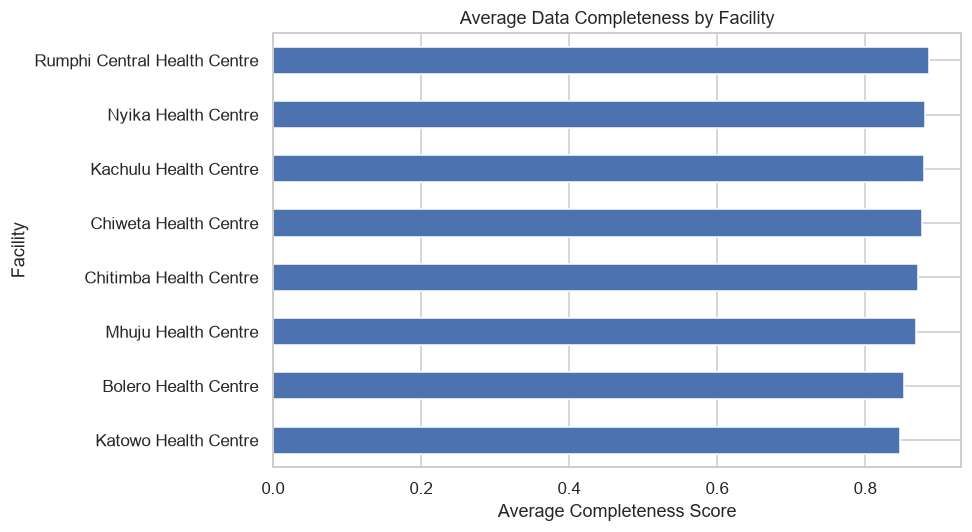

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
facility_completeness.plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("Average Completeness Score")
ax.set_ylabel("Facility")
ax.set_title("Average Data Completeness by Facility")
plt.tight_layout()
plt.savefig("../visuals/charts/01_completeness_by_facility.png", dpi=140, bbox_inches="tight")
plt.show()


### 5.2 By programme area


In [12]:
programme_completeness = df.groupby("Programme")["Completeness_Score"].mean().sort_values()
programme_completeness


Programme
Maternal Health   0.86
Child Health      0.87
TB                0.87
Outpatient        0.88
HIV               0.88
Name: Completeness_Score, dtype: float64

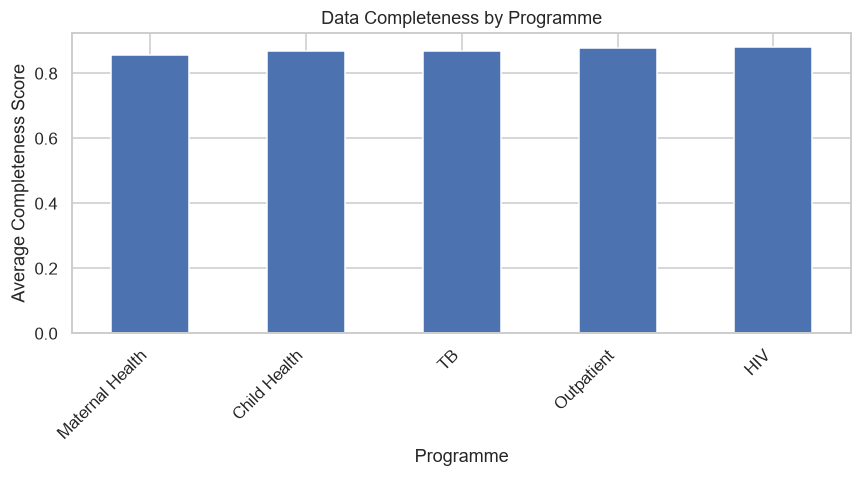

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))
programme_completeness.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_ylabel("Average Completeness Score")
ax.set_xlabel("Programme")
ax.set_title("Data Completeness by Programme")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../visuals/charts/02_completeness_by_programme.png", dpi=140, bbox_inches="tight")
plt.show()


## 6. Data Quality Assessment — Timeliness


In [14]:
timeliness = df.groupby("Facility")["Timeliness"].apply(lambda x: (x == "On Time").mean()).sort_values()
timeliness


Facility
Kachulu Health Centre          0.74
Rumphi Central Health Centre   0.78
Chitimba Health Centre         0.80
Nyika Health Centre            0.81
Mhuju Health Centre            0.82
Bolero Health Centre           0.83
Chiweta Health Centre          0.84
Katowo Health Centre           0.85
Name: Timeliness, dtype: float64

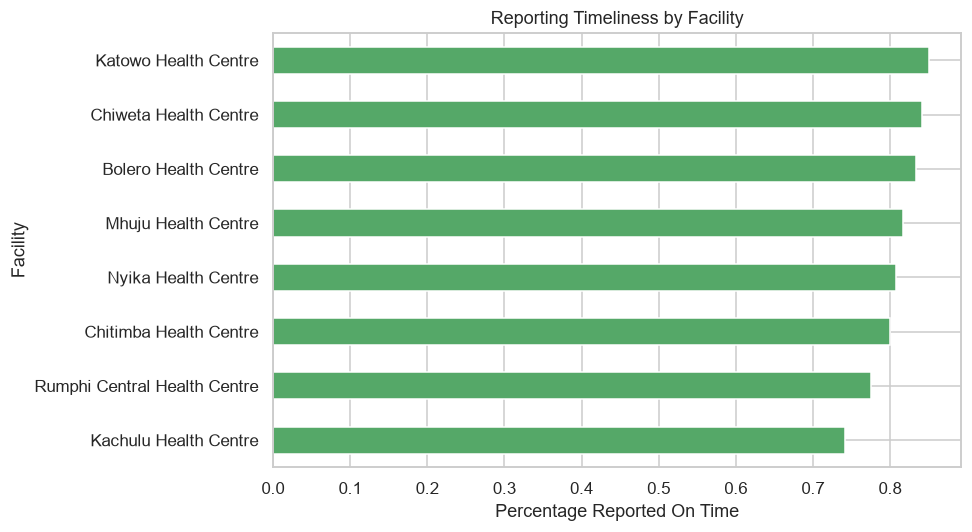

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
timeliness.plot(kind="barh", ax=ax, color="#55A868")
ax.set_xlabel("Percentage Reported On Time")
ax.set_ylabel("Facility")
ax.set_title("Reporting Timeliness by Facility")
plt.tight_layout()
plt.savefig("../visuals/charts/03_timeliness_by_facility.png", dpi=140, bbox_inches="tight")
plt.show()


## 7. Source Discrepancies by Facility

Where are the paper/EMR/DHIS2 disagreements concentrated?


In [16]:
discrepancies = (
    df[df["Consistency_Flag"] == "Review Required"]
    .groupby("Facility").size().sort_values(ascending=False)
)
discrepancies


Facility
Chiweta Health Centre           53
Bolero Health Centre            50
Kachulu Health Centre           49
Chitimba Health Centre          45
Rumphi Central Health Centre    44
Nyika Health Centre             39
Mhuju Health Centre             37
Katowo Health Centre            33
dtype: int64

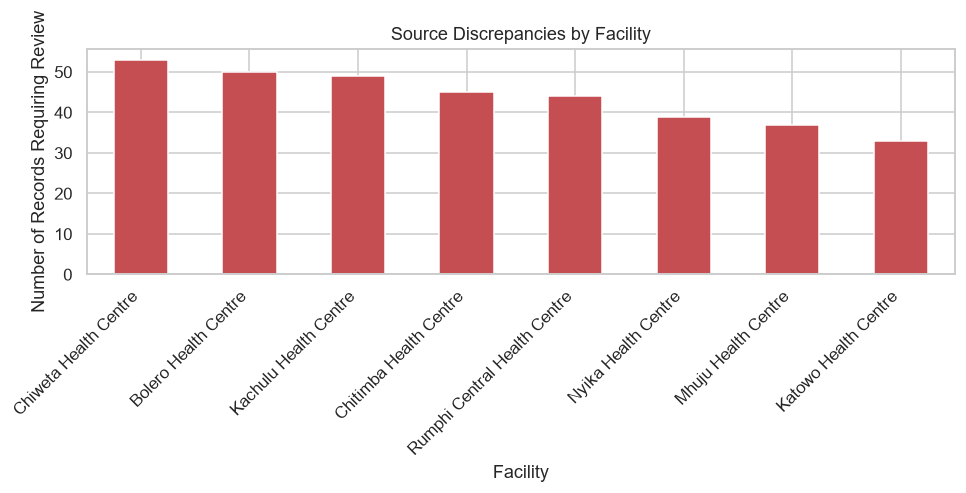

In [17]:
fig, ax = plt.subplots(figsize=(9, 4.5))
discrepancies.plot(kind="bar", ax=ax, color="#C44E52")
ax.set_ylabel("Number of Records Requiring Review")
ax.set_xlabel("Facility")
ax.set_title("Source Discrepancies by Facility")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../visuals/charts/04_source_discrepancies_by_facility.png", dpi=140, bbox_inches="tight")
plt.show()


## 8. Validity — Outlier Detection

A simple IQR (interquartile range) rule, applied **within each Programme + Indicator group** rather than globally — a value that's a huge outlier for "New TB Cases" might be perfectly normal for "OPD Visits", so the bounds have to be computed separately per indicator.


In [18]:
def detect_outliers(group):
    q1 = group["Reported_Value"].quantile(0.25)
    q3 = group["Reported_Value"].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (group["Reported_Value"] < lower) | (group["Reported_Value"] > upper)

df["Outlier_Flag"] = (
    df.groupby(["Programme", "Indicator"], group_keys=False)
    .apply(lambda x: pd.Series(detect_outliers(x).values, index=x.index))
)

df["Outlier_Flag"].value_counts()


Outlier_Flag
False    946
True      14
Name: count, dtype: int64

The count flagged here should be in the neighborhood of the 2% outlier-injection rate from Section 1 (some genuinely extreme but non-injected values may also get caught by the IQR rule, which is expected — IQR is a general-purpose statistical rule, not a detector tuned specifically to this dataset's injection logic).


## 9. Unified Data-Quality Flag

Each record can have multiple problems at once. For a single, prioritized "primary issue" label (used in the dashboard's issue-management view), problems are checked in this priority order: missing data first (most severe — no data to assess at all), then source discrepancy, late reporting, potential outlier, and finally low completeness.


In [19]:
conditions = [
    df["Reported_Value_Missing"],
    df["Consistency_Flag"] == "Review Required",
    df["Timeliness"] == "Late",
    df["Outlier_Flag"] == True,
    df["Completeness_Score"] < 0.80,
]
choices = ["Missing Data", "Source Discrepancy", "Late Reporting", "Potential Outlier", "Low Completeness"]

df["Primary_Issue"] = np.select(conditions, choices, default="No Major Issue")
df["Primary_Issue"].value_counts()


Primary_Issue
No Major Issue        423
Source Discrepancy    339
Late Reporting        121
Low Completeness       44
Missing Data           28
Potential Outlier       5
Name: count, dtype: int64

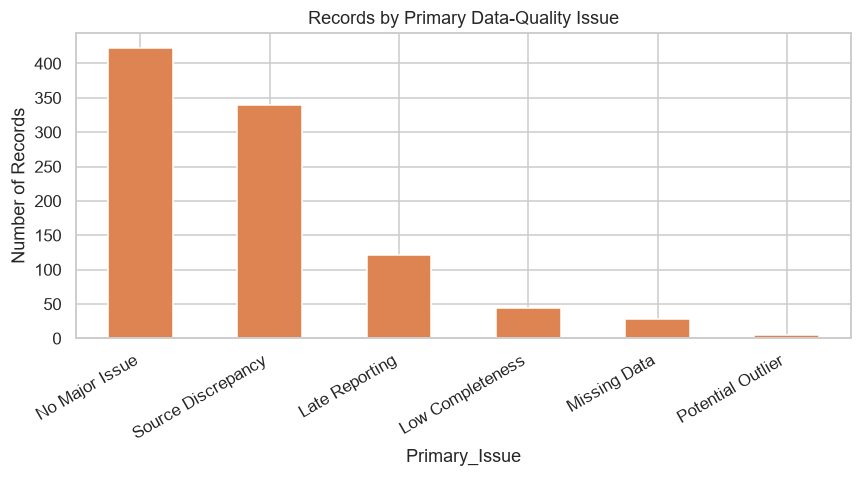

In [20]:
fig, ax = plt.subplots(figsize=(8, 4.5))
df["Primary_Issue"].value_counts().plot(kind="bar", ax=ax, color="#DD8452")
ax.set_ylabel("Number of Records")
ax.set_title("Records by Primary Data-Quality Issue")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("../visuals/charts/05_primary_issue_counts.png", dpi=140, bbox_inches="tight")
plt.show()


## 10. Ranking Facilities by Data-Quality Risk

This is the step that turns the assessment into something an M&E Officer could actually act on: a single risk score per facility, combining every dimension above.

**The weights below are a demonstration scoring rule, not a validated risk model** — they're chosen to be directionally sensible (weighting incompleteness most heavily, then giving equal-ish weight to discrepancies, missing records, and late/outlier counts) but a real deployment would need these calibrated against what the organisation actually cares about most.


In [21]:
facility_quality = df.groupby("Facility").agg(
    Average_Completeness=("Completeness_Score", "mean"),
    Late_Reports=("Timeliness", lambda x: (x == "Late").sum()),
    Source_Discrepancies=("Consistency_Flag", lambda x: (x == "Review Required").sum()),
    Missing_Records=("Reported_Value_Missing", "sum"),
    Outliers=("Outlier_Flag", "sum"),
)

facility_quality["Risk_Score"] = (
    (1 - facility_quality["Average_Completeness"]) * 100
    + facility_quality["Late_Reports"] * 1.5
    + facility_quality["Source_Discrepancies"] * 2
    + facility_quality["Missing_Records"] * 2
    + facility_quality["Outliers"] * 1.5
)

facility_quality = facility_quality.sort_values("Risk_Score", ascending=False)
facility_quality.round(2)


,Average_Completeness,Late_Reports,Source_Discrepancies,Missing_Records,Outliers,Risk_Score
Facility,,,,,,
Kachulu Health Centre,0.88,31,49,3,2,165.52
Chiweta Health Centre,0.88,19,53,5,2,159.83
Chitimba Health Centre,0.87,24,45,4,3,151.41
Bolero Health Centre,0.85,20,50,3,0,150.72
Rumphi Central Health Centre,0.89,27,44,2,2,146.92
Nyika Health Centre,0.88,23,39,2,4,134.38
Mhuju Health Centre,0.87,22,37,4,0,128.14
Katowo Health Centre,0.85,18,33,5,1,119.80


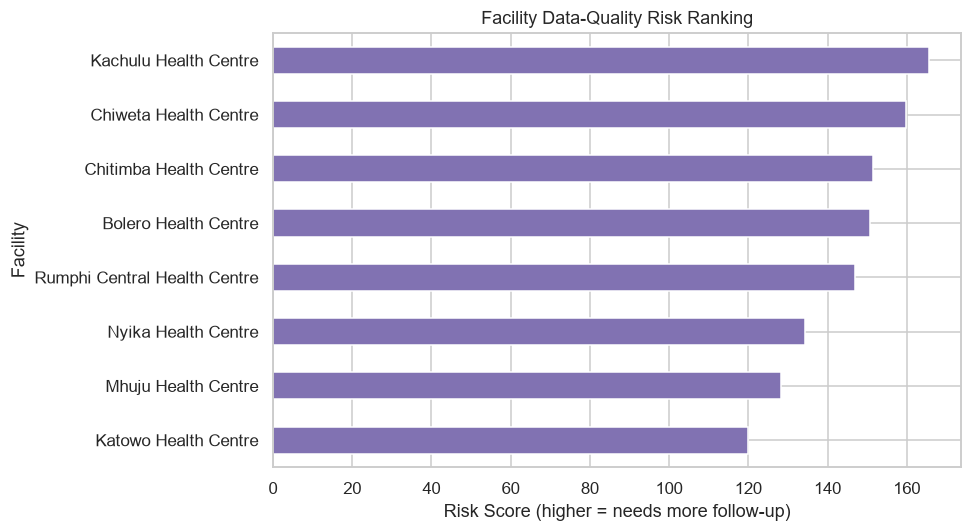

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))
facility_quality["Risk_Score"].sort_values().plot(kind="barh", ax=ax, color="#8172B2")
ax.set_xlabel("Risk Score (higher = needs more follow-up)")
ax.set_title("Facility Data-Quality Risk Ranking")
plt.tight_layout()
plt.savefig("../visuals/charts/06_facility_risk_ranking.png", dpi=140, bbox_inches="tight")
plt.show()


## 11. Monthly Reporting Trends by Programme

Aggregate reported values (as actually recorded — including the injected problems, since this is a reporting-volume trend, not a cleaned indicator series) by month and programme.


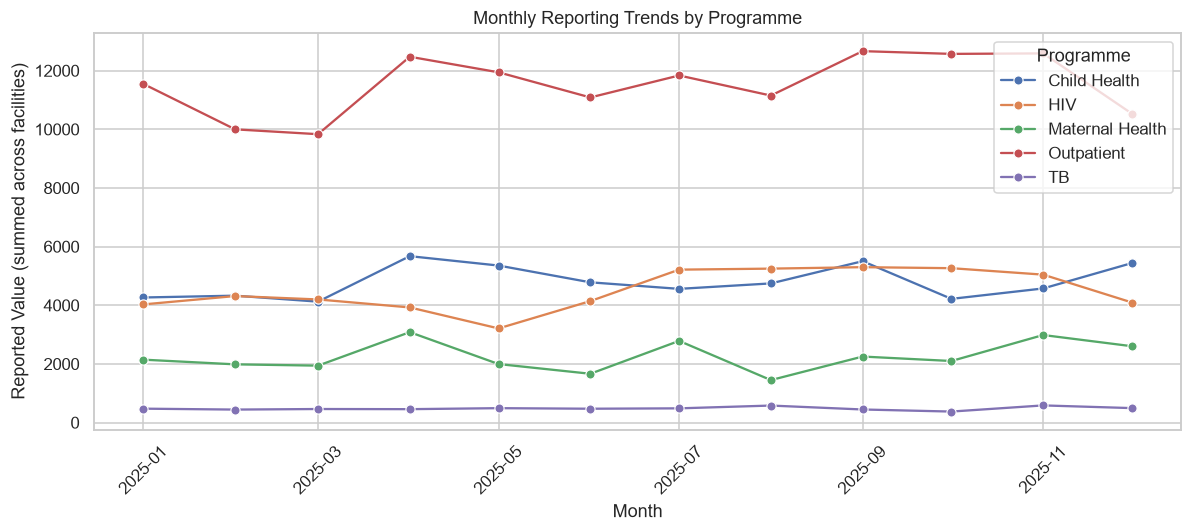

In [23]:
monthly_trends = df.groupby(["Month", "Programme"])["Reported_Value"].sum().reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(data=monthly_trends, x="Month", y="Reported_Value", hue="Programme", marker="o", ax=ax)
ax.set_title("Monthly Reporting Trends by Programme")
ax.set_xlabel("Month")
ax.set_ylabel("Reported Value (summed across facilities)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../visuals/charts/07_monthly_trends_by_programme.png", dpi=140, bbox_inches="tight")
plt.show()


## 12. Final Data-Quality Summary

The headline metrics that would sit on the dashboard's Executive Overview page.


In [24]:
overall_completeness = df["Completeness_Score"].mean()
timely_reporting = (df["Timeliness"] == "On Time").mean()
consistency_rate = (df["Consistency_Flag"] == "Consistent").mean()
total_issues = (df["Primary_Issue"] != "No Major Issue").sum()
facilities_needing_followup = (facility_quality["Risk_Score"] > facility_quality["Risk_Score"].median()).sum()

print(f"Overall completeness:              {overall_completeness:.1%}")
print(f"Timely reporting:                  {timely_reporting:.1%}")
print(f"Source consistency:                {consistency_rate:.1%}")
print(f"Records requiring attention:       {total_issues:,} of {len(df):,} ({total_issues/len(df):.1%})")
print(f"Facilities above median risk score: {facilities_needing_followup} of {df['Facility'].nunique()}")


Overall completeness:              87.0%
Timely reporting:                  80.8%
Source consistency:                63.5%
Records requiring attention:       537 of 960 (55.9%)
Facilities above median risk score: 4 of 8


## 13. Export Cleaned Dataset

This becomes the single source of truth for the Power BI dashboard.


In [25]:
output_directory = Path("../data/processed")
output_directory.mkdir(parents=True, exist_ok=True)
output_file = output_directory / "cleaned_health_facility_data.csv"
df.to_csv(output_file, index=False)
print(f"Saved: {df.shape[0]:,} rows x {df.shape[1]} columns -> {output_file}")


Saved: 960 rows x 20 columns -> ..\data\processed\cleaned_health_facility_data.csv


### Recap

1. **Generated** a synthetic but realistic dataset (8 facilities x 12 months x 10 indicators x 3 sources), with a fixed seed for reproducibility, and explicitly injected 4 categories of data-quality problems.
2. **Inspected** the raw data and confirmed the injected missingness was where expected.
3. **Cleaned** it — dates, numeric coercion, completeness clipping — while deliberately *not* imputing missing reports with zero or an average, tracking missingness as a flag instead.
4. **Validated** cross-source consistency (Paper/EMR/DHIS2) against a stated, demonstration threshold.
5. Assessed **completeness** and **timeliness** by facility and programme.
6. Detected **outliers** with a per-indicator IQR rule.
7. Combined everything into a single prioritized **Primary_Issue** flag and a per-facility **Risk_Score**.
8. Reviewed **monthly trends** by programme.
9. **Exported** the cleaned dataset for the Power BI dashboard.

Every number in this notebook is a direct calculation on the dataset generated in Section 1 — nothing was asserted without being computed here first, and every injected-problem rate was checked against what the detection logic actually found.
